In [ ]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib inline

dataset = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Copy of Bostan (1).csv")
dataset.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [ ]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [ ]:
#Splitting
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0)

In [ ]:
import seaborn as sns
#Using Pearson Correlation
plt.figure(figsize=(10,8))
cor = X_train.corr()

<Figure size 1000x800 with 0 Axes>

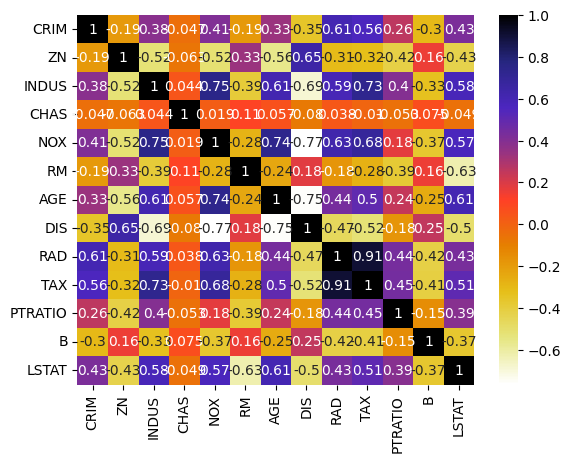

In [ ]:
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
#cmap=plt.cm.CMRmap_r
plt.show()

In [ ]:
def correlation(dataset, threshold):
  col_corr = set() # Set of all the names of correlated columns
  corr_matrix = dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i, j]) > threshold:
        colname = corr_matrix.columns[i] # getting the name of column
        col_corr.add(colname)
  return col_corr

In [ ]:
corr_features = correlation(X_train, 0.7)
corr_features

{'AGE', 'DIS', 'NOX', 'TAX'}

In [ ]:
X_train.drop(corr_features, axis = 1)
X_test.drop(corr_features, axis = 1)

,CRIM,ZN,INDUS,CHAS,RM,RAD,PTRATIO,B,LSTAT
329,0.06724,0.0,3.24,0.0,6.333,4,16.9,375.21,7.34
371,9.23230,0.0,18.10,0.0,6.216,24,20.2,366.15,9.53
219,0.11425,0.0,NaN,1.0,6.373,5,16.4,393.74,10.50
403,24.80170,0.0,18.10,0.0,5.349,24,20.2,396.90,19.77
78,0.05646,0.0,12.83,0.0,6.232,5,18.7,386.40,12.34
...,...,...,...,...,...,...,...,...,...
4,0.06905,0.0,2.18,0.0,7.147,3,18.7,396.90,NaN
428,7.36711,0.0,18.10,0.0,6.193,24,20.2,96.73,21.52
385,16.81180,0.0,18.10,0.0,5.277,24,20.2,396.90,30.81
308,0.49298,0.0,9.90,0.0,6.635,4,18.4,396.90,4.54


In [ ]:
##2. Forward Feature Selection
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [ ]:
# Generate sample dataset
X, y = make_regression(
n_samples=100,
n_features=5,
noise=10,
random_state=42
)
print("Dataset Size:", X.shape)

Dataset Size: (100, 5)


In [ ]:
# Convert to DataFrame
feature_names = [f'X{i}' for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)

In [ ]:
#Multiple Regression Model
model = LinearRegression()
selected_features = [] #Initially empty set{}
remaining_features = list(X.columns) #Initially set with all features{X0', 'X1', 'X2', 'X3', 'X4'}

print("Remaining features are: ",remaining_features)

Remaining features are:  ['X0', 'X1', 'X2', 'X3', 'X4']


In [ ]:
while remaining_features:
    scores_with_candidates = []
    for feature in remaining_features:
        # Try adding one feature
        candidate_features = selected_features + [feature]
        X_candidate = X[candidate_features]
        # Cross-validated R2 score
        score = cross_val_score(model, X_candidate, y, cv=5, scoring='r2').mean()
        scores_with_candidates.append((score, feature))
        # Select best feature
    best_score, best_feature = max(scores_with_candidates)
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    print(f"Added feature: {best_feature}, R2 score: {best_score:.4f}")

Added feature: X1, R2 score: 0.3456
Added feature: X0, R2 score: 0.5909
Added feature: X3, R2 score: 0.7220
Added feature: X2, R2 score: 0.9217
Added feature: X4, R2 score: 0.9931


In [ ]:
print("\nFinal selected feature order:")
print(selected_features)


Final selected feature order:
['X1', 'X0', 'X3', 'X2', 'X4']


In [1]:
#3Feature selection with LASSO regression
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.80050009,  1.06548848,  1.29708846, ..., -0.05449919,
         0.41853093, -0.37098854],
       [-0.03956713, -0.93853666, -1.08218016, ..., -0.83030083,
        -1.43658851, -1.93847913],
       [ 1.79330681,  1.06548848,  0.93453324, ..., -0.05449919,
         0.06015558, -0.54515416],
       ...,
       [ 0.87686984,  1.06548848, -0.33441002, ..., -0.23293356,
        -0.98564884,  0.32567395],
       [-0.9560041 , -0.93853666,  0.82123474, ...,  0.55838411,
         0.93616291, -0.54515416],
       [-0.9560041 , -0.93853666, -1.53537419, ..., -0.83030083,
        -0.08875225,  0.06442552]])

In [3]:
lasso = Lasso(alpha=0.1) # alpha = λ (regularization strength)
lasso.fit(X_scaled, y)

Lasso(alpha=0.1)

In [4]:
coefficients = pd.Series(lasso.coef_, index=X.columns)
print("LASSO Coefficients:")
print(coefficients)

LASSO Coefficients:
age    -0.277693
sex   -11.159488
bmi    24.855184
bp     15.242133
s1    -26.448140
s2     13.725663
s3     -0.000000
s4      7.055574
s5     31.575062
s6      3.158477
dtype: float64


In [5]:
selected_features = coefficients[coefficients != 0].index.tolist()
print("\nSelected Features:")
print(selected_features)


Selected Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's4', 's5', 's6']


In [6]:
# Effect of Alpha (Regularization Strength):
for alpha in [0.01, 0.1, 1.0, 8]:
  lasso = Lasso(alpha=alpha)
  lasso.fit(X_scaled, y)
  non_zero = np.sum(lasso.coef_ != 0)
  print(f"alpha={alpha} → selected features = {non_zero}")

alpha=0.01 → selected features = 10
alpha=0.1 → selected features = 9
alpha=1.0 → selected features = 7
alpha=8 → selected features = 4
